# Duplicate of sampling.ipynb for doing repeated runs

## 0.1. Imports and load data

In [2]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester, extract_latent_space
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 50
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
trainer = Trainer(
    max_epochs=MAX_EPOCHS, early_stopping=True, patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)
tester = Tester(device=DEVICE)
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)


In [3]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static_2e2o.xyz"
BASE_N_GEOMETRIES = '3731'  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "A02_propene_grid_static_4e4o.xyz"
TRANSFER_N_GEOMETRIES = '3731' # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"
RESULTS_CSV = OUTPUT_DIR / "results" / "repeated_runs_results.csv"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 3731
transfer_atoms_list length: 3731


## 0.2. Split into test, train, valid sets

In [4]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]

# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.2 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("\nBase train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Test set size: 361

Base train set size: 2621
Base valid set size: 749

Full high-fidelity train set size: 2621
Full high-fidelity valid set size: 749


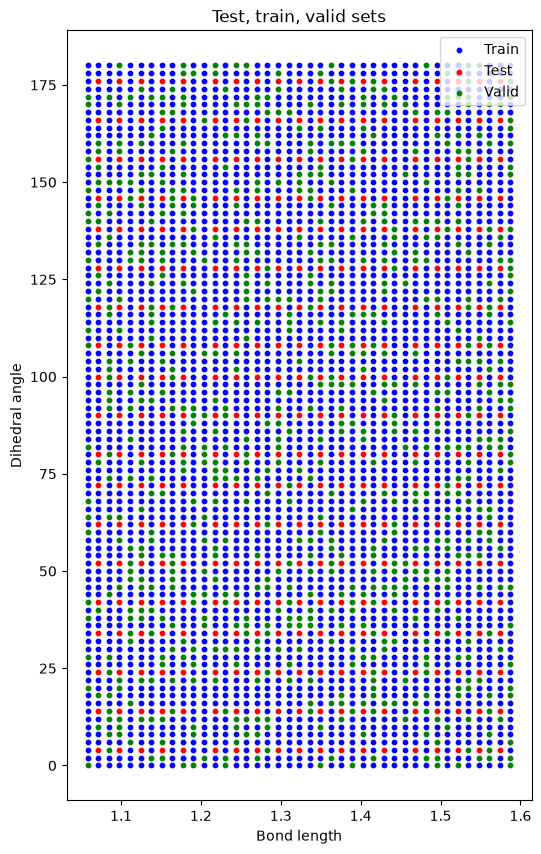

In [4]:
# visualise
plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, label='Train')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid')

plt.title("Test, train, valid sets")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Train base model



In [ ]:
base_train_loader = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=True
)
base_valid_loader = data_builder.load(
    base_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
base_test_loader = data_builder.load(
    base_test_set, batch_size=BATCH_SIZE, shuffle=False
)
torch.manual_seed(SEED)

base_model = initialise_autoencoder(data_builder.get_metadata(), preset="lightweight")
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=BASE_LR)

base_model, base_history = trainer.train_model(
    base_model, base_train_loader, base_valid_loader, base_optimizer, loss_fn
)

tester.run_test(base_model, base_test_loader)
base_energy_mae = tester.get_energy_mae()
base_encoder = base_model.perm_encoder
{"best_epoch": base_history["best_epoch"], "test_energy_mae_ev": base_energy_mae}


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

Epoch 001 | train_loss=112.202106 | valid_loss=131.505759
Epoch 002 | train_loss=100.455847 | valid_loss=124.357864
Epoch 003 | train_loss=76.450234 | valid_loss=54.080552
Epoch 004 | train_loss=41.250764 | valid_loss=35.191094
Epoch 005 | train_loss=30.699862 | valid_loss=28.692574
Epoch 006 | train_loss=28.165526 | valid_loss=27.144892
Epoch 007 | train_loss=26.770702 | valid_loss=26.186961
Epoch 008 | train_loss=25.932211 | valid_loss=24.645659
Epoch 009 | train_loss=25.173279 | valid_loss=24.603856
Epoch 010 | train_loss=24.889473 | valid_loss=23.767618


{'best_epoch': 10, 'test_energy_mae_ev': 1.416432499885559}

In [ ]:
# save model
base_model_filename = "base_model_propene_500_geometries_for_pca_testing.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
torch.save(base_model, base_model_save_path)
print(f"Base model saved to {base_model_save_path}")


Base model saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/base_models/base_model_propene_500_geometries_for_pca_testing.pt


## 1. Choose descriptor

In [5]:
# this will overwrite the base model from the previous section
# run this to load the base model from file instead of using previous section

base_model_filename = "base_propene_3731_geom_2e2o_50_epoch.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
base_model = torch.load(base_model_save_path, weights_only=False)

base_model.eval()

base_encoder = base_model.perm_encoder

In [6]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr", "latent_space"]
DESCRIPTOR = DESCRIPTOR_TYPE[8]  # choose the descriptor type to use

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
if DESCRIPTOR == "latent_space":
    base_train_loader_unshuffle = data_builder.load(
        base_train_set, batch_size=BATCH_SIZE, shuffle=False
    )
    latent_space = extract_latent_space(
        base_model, base_train_loader_unshuffle, device=DEVICE
    )
    desc_matrix = latent_space
else:
    for atom in base_train_set:
        desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


desc_matrix shape: (2621, 16)
desc_matrix unique shape: (2621, 16)
desc_matrix:
 [[-1.2043107   0.12062885 -0.5591501  ... -1.3333194   1.785672
   0.89981747]
 [-1.1806495   0.3279398  -0.6525512  ... -1.1673815   1.9771845
   0.7567266 ]
 [-1.1784194   0.13344683 -0.55593956 ... -1.3393573   1.8132535
   0.90219486]
 ...
 [-1.1842715   0.14935547 -0.5658525  ... -1.3272974   1.8163601
   0.88567406]
 [-1.1548558   0.20012797 -0.5801444  ... -1.2892287   1.8898118
   0.86431587]
 [-1.179636    0.11040238 -0.545122   ... -1.3495538   1.801417
   0.92102206]]


In [ ]:
# optional dimensionality reduction using PCA

PCA_DIMENSIONS = 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=PCA_DIMENSIONS)
desc_matrix = pca.fit_transform(desc_matrix_scaled)

print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 3)
desc_matrix unique shape: (500, 3)
desc_matrix:
 [[ 25.66290073  -7.5435525    3.57461524]
 [-17.68889132  -1.97186744 -11.88806588]
 [ -9.68128667   8.30790249  11.93837659]
 ...
 [ -4.73528134  13.40840203  -1.75137886]
 [ -0.93051678  -9.05129291  -4.19616038]
 [ -3.10642808 -11.28432425  -3.91061191]]


## 2. Choose selector

In [ ]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "k_means_clustering_weighted", "birch", "birch_weighted", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[3]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=25)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))


n clusters: 25
n clusters with samples: 25
labels: [13  5 14 ... 23 15 24]
allocation: [2 9 2 3 5 2 4 7 2 2 2 2 2 8 7 3 4 4 4 3 2 3 8 5 5]
sampled indices:
 [2577  164 2607 1527 2122 1137  755 2537 2203  259  548 2182 1368 1410
  148  294 1305  157 1595  857 1695  274  680  530 2010 2162 1778 1280
 2574 1599  576  825 2005 2343 2007 2003 2118 1303 2202 1372   57 1680
 1788 2605 1483 1954  874 1853 2195 1471 1367  228 1899 2167  539 2329
 1333 2099 2046 1265 1848  653  262 1693 1183 2575 2225 1041 2279 1623
  133   63 1486  116  721   48 2236  515 2540 1923 1161  166  491 2200
 1435 1519  231 1613  243  725   25 2033  678 1160  181 2496 1543 2103
 2073  785]
number sampled: 100


## 3. Repeated runs of training transfer model

In [7]:
results = []


In [8]:
N_REPEATS = 25
import time

# load train, valid, test sets
full_valid_loader = data_builder.load(
    transfer_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
full_test_loader = data_builder.load(
    transfer_test_set, batch_size=BATCH_SIZE, shuffle=False
)

for i in range(N_REPEATS):
    start = time.time()
    
    SEED = i
    torch.manual_seed(SEED)

    # select samples based on the descriptor matrix
    sampled_idx = selectors.get_selector("k_means_clustering_weighted", desc_matrix, 100, n_clusters=25, random_state=SEED)

    # sample atoms out of transfer dataset
    sampled_atoms = [transfer_train_set[j] for j in sampled_idx]

    transfer_train_loader = data_builder.load(
        sampled_atoms, batch_size=BATCH_SIZE, shuffle=True
    )

    # do the training
    transfer_model = NaiveStrategy().apply(base_model)
    transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=TRANSFER_LR)

    transfer_model, transfer_history = trainer.train_model(
        transfer_model, transfer_train_loader, full_valid_loader, transfer_optimizer, loss_fn
    )

    # do the testing
    tester.run_test(transfer_model, full_test_loader)
    transfer_best_epoch = transfer_history["best_epoch"]
    transfer_energy_mae = tester.get_energy_mae()
    
    results.append({'seed': SEED, 'best_epoch': transfer_best_epoch, 'energy_mae': transfer_energy_mae})

    print(f"seed: {SEED}, best_epoch {transfer_best_epoch}, energy_mae: {transfer_energy_mae}\n")
    print(f"duration: {time.time() - start}\n")


n clusters: 25
n clusters with samples: 25
labels: [ 0 11 13 ...  3  2 17]
allocation: [12  3  4  4  3  2 13  6  2  3  2  3  2  5  3  2  3 11  2  3  3  1  4  2
  2]
Epoch 001 | train_loss=10.008371 | valid_loss=8.182793
Epoch 002 | train_loss=6.846365 | valid_loss=6.443899
Epoch 003 | train_loss=5.726084 | valid_loss=6.238278
Epoch 004 | train_loss=5.629321 | valid_loss=5.260896
Epoch 005 | train_loss=5.067281 | valid_loss=5.179927
Epoch 006 | train_loss=4.877915 | valid_loss=5.165077
Epoch 007 | train_loss=4.829614 | valid_loss=4.988731
Epoch 008 | train_loss=4.545748 | valid_loss=4.964225
Epoch 009 | train_loss=4.561457 | valid_loss=5.057180
Epoch 010 | train_loss=4.453102 | valid_loss=5.056115
Epoch 011 | train_loss=4.501042 | valid_loss=4.824697
Epoch 012 | train_loss=4.490758 | valid_loss=4.851112
Epoch 013 | train_loss=4.643922 | valid_loss=4.910185
Epoch 014 | train_loss=4.582213 | valid_loss=4.782753
Epoch 015 | train_loss=4.491867 | valid_loss=4.732514
Epoch 016 | train_loss=4

## 4. Plot

In [9]:
# Save results to CSV
import pandas as pd

ROOT_PATH = Path.cwd()
OUTPUT_DIR = ROOT_PATH / '../outputs'
RESULTS_CSV = OUTPUT_DIR / 'results' / 'repeated_runs_results.csv'

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)
print(f'Results saved to {RESULTS_CSV}')

Results saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/results/repeated_runs_results.csv


In [ ]:
print(results_df)

    seed  best_epoch  energy_mae
0      0          41    0.667365
1      1          46    0.666578
2      2          49    0.668126
3      3          39    0.666535
4      4          49    0.672711
5      5          26    0.667895
6      6          50    0.672365
7      7          50    0.667691
8      8          44    0.675421
9      9          46    0.672480
10    10          45    0.667154
11    11          50    0.662924
12    12          48    0.663112
13    13          40    0.670252
14    14          49    0.673583
15    15          49    0.673189
16    16          49    0.674426
17    17          46    0.671069
18    18          50    0.669429
19    19          49    0.670657
20    20          50    0.668379
21    21          45    0.669053
22    22          50    0.669093
23    23          47    0.674526
24    24          41    0.672413


--- Best epochs ---
25
Mean: 44.92
Population stdev: 3.9690804980498946
Sample stdev: 4.050925820105819


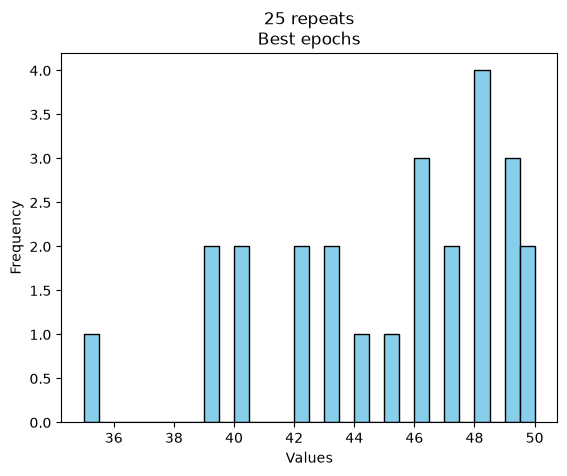

--- Energy MAEs ---
25
Mean: 0.6687184524536133
Population stdev: 0.006270975405355796
Sample stdev: 0.006400287471943585


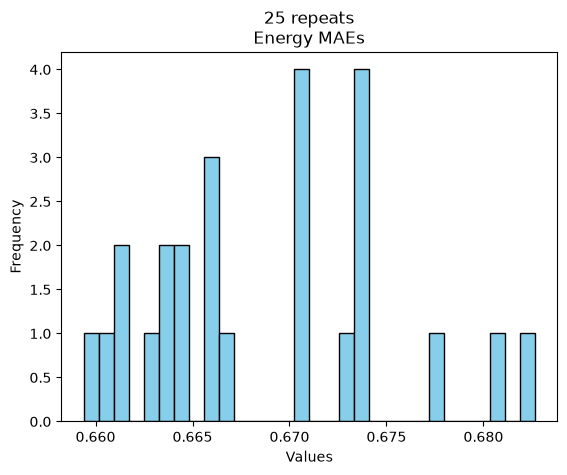

In [10]:
import matplotlib.pyplot as plt

best_epochs = results_df["best_epoch"]
energy_maes = results_df["energy_mae"]

print("--- Best epochs ---")
print(len(best_epochs))
print("Mean:", np.mean(best_epochs))
print("Population stdev:", np.std(best_epochs))
print("Sample stdev:", np.std(best_epochs, ddof=1))

plt.hist(best_epochs, bins=30, color='skyblue', edgecolor='black')

plt.title(f'{N_REPEATS} repeats\nBest epochs')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

print("--- Energy MAEs ---")
print(len(energy_maes))
print("Mean:", np.mean(energy_maes))
print("Population stdev:", np.std(energy_maes))
print("Sample stdev:", np.std(energy_maes, ddof=1))

plt.hist(energy_maes, bins=30, color='skyblue', edgecolor='black')

plt.title(f'{N_REPEATS} repeats\nEnergy MAEs')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()
